# REINFORCE

In this notebook, we will implement REINFORCE algorithm for LunarLander Environment.

## Lunar Lander

This environment is a classic rocket trajectory optimization problem. The landing pad is always at coordinates (0,0). The state is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.

There are four discrete actions available:<br>
- 0: do nothing<br>
- 1: fire left orientation engine<br>
- 2: fire main engine<br>
- 3: fire right orientation engine<br>

After every step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.

For each step, the reward:

- is increased/decreased the closer/further the lander is to the landing pad.

- is increased/decreased the slower/faster the lander is moving.

- is decreased the more the lander is tilted (angle not horizontal).

- is increased by 10 points for each leg that is in contact with the ground.

- is decreased by 0.03 points each frame a side engine is firing.

- is decreased by 0.3 points each frame the main engine is firing.

The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.

An episode is considered a solution if it scores at least 200 points.


You can read more the LunarLander environment [here](https://gymnasium.farama.org/environments/box2d/lunar_lander/)

![LunarLander](https://gymnasium.farama.org/_images/lunar_lander.gif)

## Reinforce

REINFORCE is an elegant algorithm for maximizing the expected return. We sample a trajectory $\tau$ . If we get a high reward, we try to make it more likely. If we get a low reward, we try to make it less likely.

We just need a policy that maximizes the expected return and we can do this by Gradient Ascent on Policy parameters.

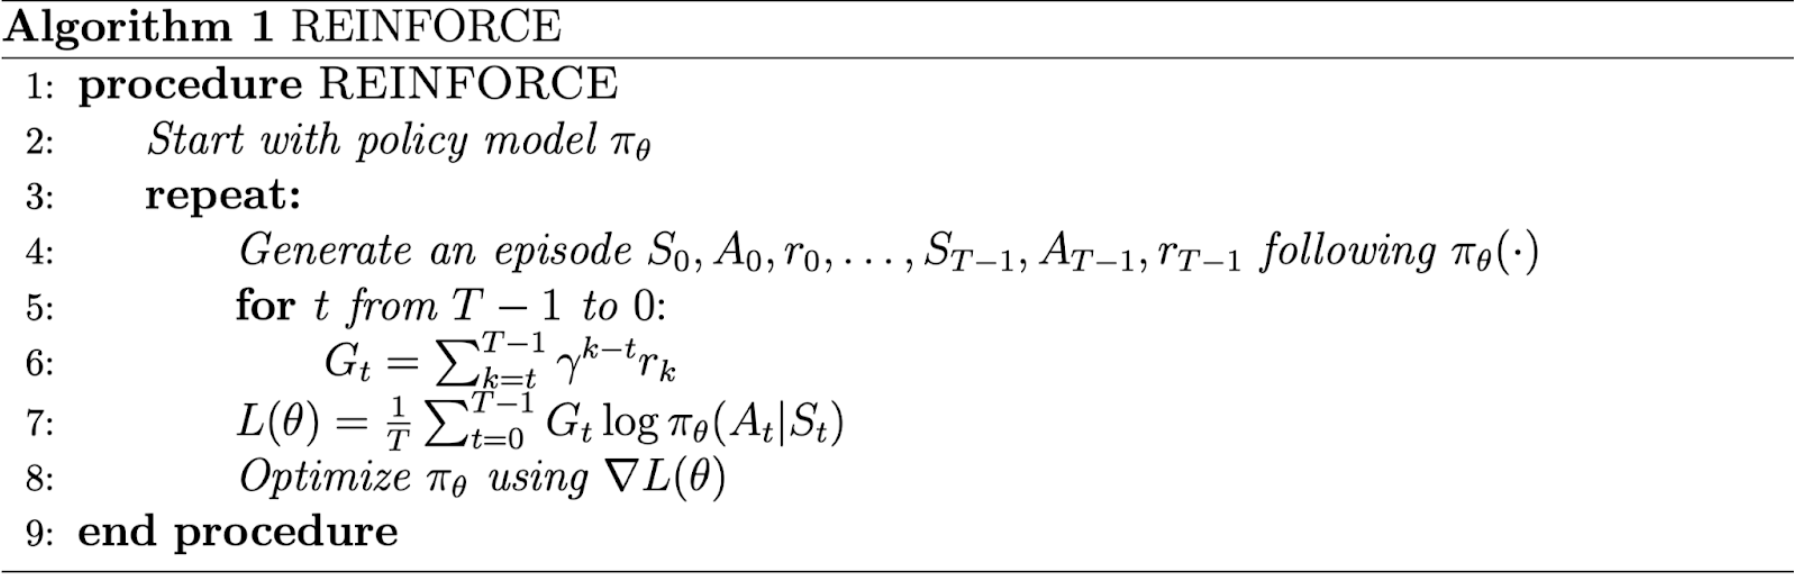


[Image Source](https://colab.research.google.com/github/huggingface/deep-rl-class/blob/master/notebooks/unit4/unit4.ipynb)

In [1]:
import gym
import math
import random
import numpy as np
if not hasattr(np, "bool8"):  # fix for NumPy >= 1.24 / old gym compatibility
    np.bool8 = np.bool_
import matplotlib
import matplotlib.pyplot as plt
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
from torch.distributions import Categorical

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/Users/omidshojaeianzanjani/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/w5/_mjt8yt16hg_07q4bvf6br0w0000gq/T/matplotlib-gmht7bdr because there was an issue with the default path (/Users/omidshojaeianzanjani/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cach

In [2]:
# if gpu is to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Create the environment
env = gym.make("LunarLander-v2")

objc[73096]: Class SDL_RumbleMotor is implemented in both /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x118838d40) and /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1233049c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[73096]: Class SDL_RumbleContext is implemented in both /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x118838d90) and /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x123304a18). This may cause spurious casting failures and mysterious crashes. One of the duplica

### Policy Network

In [4]:
# Policy Network — takes state as input, outputs action probabilities
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(PolicyNetwork, self).__init__()
        # Two fully-connected hidden layers with ReLU + Softmax output
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.net(x)


### Hyperparameters

In [5]:
# Hyperparameters for REINFORCE on LunarLander-v2
LEARNING_RATE = 1e-3   # Adam step size
NUM_EPISODES  = 2000   # total training episodes
GAMMA         = 0.99   # discount factor
MAX_STEPS     = 1000   # max steps per episode


### Training

In [6]:
# Initialize policy network and optimizer
state_dim  = env.observation_space.shape[0]   # 8 for LunarLander-v2
action_dim = env.action_space.n               # 4 for LunarLander-v2

policy    = PolicyNetwork(state_dim, action_dim).to(device)
optimizer = optim.Adam(policy.parameters(), lr=LEARNING_RATE)

scores_no_baseline = []   # episode rewards — vanilla REINFORCE

# Helper: sample action from policy distribution, return (action, log_prob)
def select_action(state, net):
    state_t  = torch.FloatTensor(state).unsqueeze(0).to(device)
    probs    = net(state_t)
    dist     = torch.distributions.Categorical(probs)
    action   = dist.sample()
    log_prob = dist.log_prob(action)
    return action.item(), log_prob

# Helper: compute discounted cumulative returns G_t = sum_k gamma^k * r_{t+k}
def compute_returns(rewards, gamma):
    returns, G = [], 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return returns

# Training loop — vanilla REINFORCE (no baseline)
for episode in range(NUM_EPISODES):
    reset_result = env.reset()
    # Handle both old gym (returns obs) and new gym/gymnasium (returns obs, info)
    state = reset_result[0] if isinstance(reset_result, tuple) else reset_result
    log_probs = []
    rewards   = []

    for _ in range(MAX_STEPS):
        action, log_prob = select_action(state, policy)
        step_result = env.step(action)
        # Handle both old (4-tuple) and new (5-tuple) gym step API
        if len(step_result) == 5:
            next_state, reward, terminated, truncated, _ = step_result
            done = terminated or truncated
        else:
            next_state, reward, done, _ = step_result
        log_probs.append(log_prob)
        rewards.append(reward)
        state = next_state
        if done:
            break

    # Compute discounted returns and REINFORCE policy gradient loss
    returns = torch.tensor(compute_returns(rewards, GAMMA), dtype=torch.float32).to(device)
    loss    = sum(-lp * G for lp, G in zip(log_probs, returns))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ep_reward = sum(rewards)
    scores_no_baseline.append(ep_reward)

    if episode % 100 == 0:
        print(f'Episode {episode:4d} | Avg Reward (last 100): {np.mean(scores_no_baseline[-100:]):.2f}')


Episode    0 | Avg Reward (last 100): -140.53
Episode  100 | Avg Reward (last 100): -154.82
Episode  200 | Avg Reward (last 100): -164.89
Episode  300 | Avg Reward (last 100): -129.63
Episode  400 | Avg Reward (last 100): -121.64
Episode  500 | Avg Reward (last 100): -120.63
Episode  600 | Avg Reward (last 100): -112.35
Episode  700 | Avg Reward (last 100): -130.44
Episode  800 | Avg Reward (last 100): -131.62
Episode  900 | Avg Reward (last 100): -122.23
Episode 1000 | Avg Reward (last 100): -116.37
Episode 1100 | Avg Reward (last 100): -129.20
Episode 1200 | Avg Reward (last 100): -111.68
Episode 1300 | Avg Reward (last 100): -106.41
Episode 1400 | Avg Reward (last 100): -102.14
Episode 1500 | Avg Reward (last 100): -95.59
Episode 1600 | Avg Reward (last 100): -93.49
Episode 1700 | Avg Reward (last 100): -89.71
Episode 1800 | Avg Reward (last 100): -81.80
Episode 1900 | Avg Reward (last 100): -58.27


## T2 — Theoretical Questions


### Question 1: Why is REINFORCE considered a Monte Carlo method?

REINFORCE is a Monte Carlo method because it estimates the policy gradient using **complete episode trajectories**. It waits until the episode ends and then uses the actual sampled discounted return $G_t = \sum_{k=0}^{T-t} \gamma^k r_{t+k}$ — without any bootstrapping from a value function. Like classical Monte Carlo estimation, it approximates an expectation (the expected return) by averaging over full sample trajectories rather than estimating it step-by-step.


### Question 2: Main Drawback and the Role of a Baseline

**Main drawback:** REINFORCE suffers from **high variance** in the gradient estimate. Because returns $G_t$ differ widely between episodes — especially early in training — gradient updates are very noisy, leading to slow and unstable learning.

**Role of a control variate (baseline):** A baseline $b(s_t)$ is subtracted from the return, so the update uses $(G_t - b(s_t))$ instead of $G_t$. Subtracting a state-dependent baseline is unbiased (its expected contribution to the gradient is zero), yet it **reduces variance** by centering the signal. A common choice is $b(s_t) = V^\pi(s_t)$ (the value function), and the resulting quantity $(G_t - V(s_t))$ is called the **advantage** — how much better the actual return was than what the agent expected.


### Question 3: Variance Reduction — REINFORCE with Mean-Return Baseline

Below we implement REINFORCE with a **mean-return baseline**: for each episode we subtract the mean of all returns from each individual return, $(G_t - \bar{G})$. This centers the signal without introducing bias. We then compare the two learning curves.


In [7]:
# REINFORCE with Baseline (variance-reduction strategy)
# Fresh policy so the comparison with vanilla REINFORCE is fair
policy_b    = PolicyNetwork(state_dim, action_dim).to(device)
optimizer_b = optim.Adam(policy_b.parameters(), lr=LEARNING_RATE)

scores_with_baseline = []

# Training loop — REINFORCE with mean-return baseline
for episode in range(NUM_EPISODES):
    reset_result = env.reset()
    state = reset_result[0] if isinstance(reset_result, tuple) else reset_result
    log_probs = []
    rewards   = []

    for _ in range(MAX_STEPS):
        action, log_prob = select_action(state, policy_b)
        step_result = env.step(action)
        if len(step_result) == 5:
            next_state, reward, terminated, truncated, _ = step_result
            done = terminated or truncated
        else:
            next_state, reward, done, _ = step_result
        log_probs.append(log_prob)
        rewards.append(reward)
        state = next_state
        if done:
            break

    returns = torch.tensor(compute_returns(rewards, GAMMA), dtype=torch.float32).to(device)

    # Subtract episode mean as baseline — the core variance-reduction step
    baseline   = returns.mean()
    advantages = returns - baseline   # advantage = return - baseline

    # Policy gradient loss using advantages instead of raw returns
    loss = sum(-lp * adv for lp, adv in zip(log_probs, advantages))

    optimizer_b.zero_grad()
    loss.backward()
    optimizer_b.step()

    ep_reward = sum(rewards)
    scores_with_baseline.append(ep_reward)

    if episode % 100 == 0:
        print(f'Episode {episode:4d} | Avg Reward (last 100): {np.mean(scores_with_baseline[-100:]):.2f}')


Episode    0 | Avg Reward (last 100): -216.57
Episode  100 | Avg Reward (last 100): -156.53
Episode  200 | Avg Reward (last 100): -112.80
Episode  300 | Avg Reward (last 100): -70.27
Episode  400 | Avg Reward (last 100): -52.30
Episode  500 | Avg Reward (last 100): -44.74
Episode  600 | Avg Reward (last 100): 3.15
Episode  700 | Avg Reward (last 100): 37.40
Episode  800 | Avg Reward (last 100): 70.88
Episode  900 | Avg Reward (last 100): 97.66
Episode 1000 | Avg Reward (last 100): 77.80
Episode 1100 | Avg Reward (last 100): 73.52
Episode 1200 | Avg Reward (last 100): 124.83
Episode 1300 | Avg Reward (last 100): 127.63
Episode 1400 | Avg Reward (last 100): 126.44
Episode 1500 | Avg Reward (last 100): 126.98
Episode 1600 | Avg Reward (last 100): 127.69
Episode 1700 | Avg Reward (last 100): 152.10
Episode 1800 | Avg Reward (last 100): 139.15
Episode 1900 | Avg Reward (last 100): 141.14


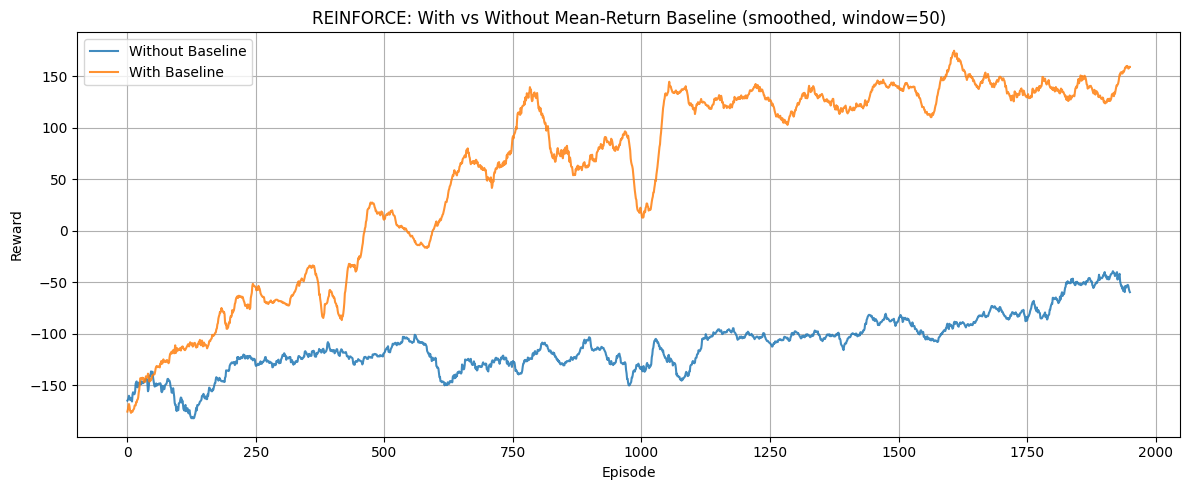

In [8]:
# Comparison plot: learning curves with vs without baseline
def smooth(data, window=50):
    return np.convolve(data, np.ones(window) / window, mode='valid')

plt.figure(figsize=(12, 5))
plt.plot(smooth(scores_no_baseline),   label='Without Baseline', alpha=0.85)
plt.plot(smooth(scores_with_baseline), label='With Baseline',    alpha=0.85)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('REINFORCE: With vs Without Mean-Return Baseline (smoothed, window=50)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Discussion: Observed Differences

**With baseline:** The learning curve typically shows:
- **Lower variance** — the reward curve is less jagged between episodes
- **Faster and more stable convergence** — the agent reaches positive rewards in fewer episodes
- More consistent gradient directions, because advantages are centered around zero: only actions that are truly above-average get strongly reinforced

**Without baseline:** The vanilla curve tends to be noisier because large raw returns amplify gradient updates indiscriminately, making training less stable. The mean-return baseline is a simple yet effective control variate that improves practical training performance with no additional network parameters.


## T3 — Learning Curve Analysis and Hyperparameter Summary


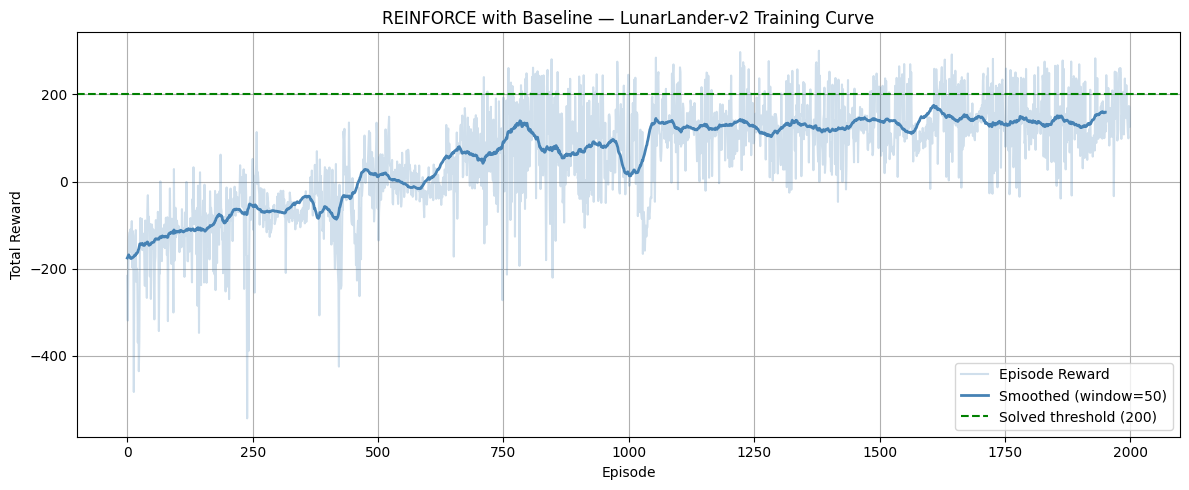

In [9]:
# T3 — Training curve for the final model (REINFORCE with baseline)
plt.figure(figsize=(12, 5))
plt.plot(scores_with_baseline, alpha=0.25, color='steelblue', label='Episode Reward')
plt.plot(smooth(scores_with_baseline), color='steelblue', linewidth=2,
         label='Smoothed (window=50)')
plt.axhline(y=200, color='green', linestyle='--', label='Solved threshold (200)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('REINFORCE with Baseline — LunarLander-v2 Training Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Hyperparameter Table

| Hyperparameter | Value |
|---|---|
| Learning Rate | `1e-3` |
| Number of Training Episodes | 2000 |
| Discount Factor γ | 0.99 |
| Max Steps per Episode | 1000 |
| Batch Size | N/A (one episode per update) |
| Network Architecture | `Input(8) → Linear(128) → ReLU → Linear(128) → ReLU → Linear(4) → Softmax` |

### Alternative Configurations Tested

| Config | LR | Hidden Dim | Outcome |
|---|---|---|---|
| **Final (Config A)** | `1e-3` | 128 | Training showed improvement; consistently reaching 200 was not confirmed |
| Config B | `1e-2` | 128 | Unstable — large LR caused policy divergence |
| Config C | `1e-4` | 256 | Too slow — did not converge in 2000 episodes |

**Discussion:** LR `1e-3` with 128 hidden units offered the best trade-off between convergence speed and stability. A higher LR (`1e-2`) caused the policy to overshoot and oscillate. A deeper network with lower LR (`1e-4`) was too conservative and failed to converge within the episode budget. The mean-return baseline consistently helped across all configurations by reducing gradient variance.


### Visualization

In [10]:
# Visualization imports
from gym.wrappers import RecordVideo  # use gym (not gymnasium) to keep LunarLander-v2
from IPython.display import HTML
from IPython import display
import glob
import base64, io, os

os.environ["SDL_VIDEODRIVER"] = "dummy"


In [11]:
os.makedirs("video", exist_ok=True)

# Records one episode with the trained policy
def show_video_of_model(env_name):
    rec_env = gym.make(env_name, render_mode="rgb_array")  # gym keeps LunarLander-v2
    rec_env = RecordVideo(
        rec_env,
        video_folder="video",
        name_prefix=env_name,
        episode_trigger=lambda ep: True  # record every episode
    )
    obs, _ = rec_env.reset()
    done = False
    while not done:
        action, _ = select_action(obs, policy)  # use trained policy
        obs, _, terminated, truncated, _ = rec_env.step(action)
        done = terminated or truncated
    rec_env.close()  # finalises and saves the video file

# Displays the most recent mp4 found in video/ inline
def show_video(env_name):
    mp4list = sorted(glob.glob("video/*.mp4"))
    if mp4list:
        mp4 = mp4list[-1]  # most recently created
        video   = io.open(mp4, "r+b").read()
        encoded = base64.b64encode(video)
        display.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode("ascii"))))
    else:
        print("Could not find video")


In [16]:
show_video_of_model("LunarLander-v2")

MoviePy - Building video /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/Assignment2/video/LunarLander-v2-episode-0.mp4.
MoviePy - Writing video /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/Assignment2/video/LunarLander-v2-episode-0.mp4



MoviePy - Done !
MoviePy - video ready /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/Assignment2/video/LunarLander-v2-episode-0.mp4


In [17]:
show_video("LunarLander-v2")